# Trio (DIAGONALLY-n-SUMMED, normalized currents): loc vs disp vs exact — deterministic, lattice prop, $L=1,2$

The lattice estimator, Eq.(4.29) (qed3int_v2-13) — **no $1/(D-1)$ in front**; this is exactly what the code computes (unchanged):
$$
\hat G^s_{\rm lat}(t)=\frac{1}{4\pi}\sum_{\langle n,n'\rangle} A_{nn'}\,\langle J_{\rm norm}(nn',0)\,J_{\rm norm}(nn',t)\rangle,
\qquad
\hat G^t_{\rm lat}(t)=\frac{1}{4\pi}\sum_n A_n\,\langle J_{\rm norm}^{0,1}(n)\,J_{\rm norm}^{t,t+1}(n)\rangle,
$$
$J_{\rm norm}=J_{ov\kappa}=J/\kappa$; weight = **area** (`link_volume` sp, `dual_areas` tp), $1/(4\pi)$ folded by `write_corr`.
The physical spatial correlator is the per-direction average $G^s\equiv\frac{\delta^{ab}-e_3^a e_3^b}{D-1}f^{ab}$ (Eq.4.28),
so $G^s/G^t=-1$.

**How each operator maps to $G^s$ (per-direction):**
- **disp / exact** are LINK currents.  The diagonal $\langle j_e j_e\rangle$ on one link is already the single
  per-direction value $g$ ($\hat e$ a unit vector, $\langle j^a j^b\rangle=g\,\delta^{ab}$); the area-weighted link
  sum just averages that to $g$.  So $\hat G^s_{\rm lat}=G^s$ directly — **no $1/(D-1)$**, ratio $-1$ raw.
- **loc** uses on-site $\sigma^a$ and sums **both** spatial Pauli channels $s_1+s_2 = (D{-}1)g$, so loc alone
  needs $G_s=(s_1{+}s_2)/(D{-}1)$ to give the per-direction value.

Loaders: $G_t=$`tp`(or `s3`) for all; $G_s=$`sp` for disp/exact, $(s_1{+}s_2)/(D{-}1)$ for loc.

**CHECK:** all three give $G_s/G_t\to-1$ (opposite signs).

In [9]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

dir1 = '/mnt/barracuda22/qed3/qed3/src/both_3d/'
ESN  = dir1 + 'data_free_vmRe0.000000vmIm0.000000/'
at_cft = 0.2
Nt_cft = 128
Delta_cft = 2.0
Dm1 = 2.0   # D - 1 : ONLY for loc (which sums BOTH spatial Pauli channels s1+s2 = D-1 directions).
tag = ''    # '' = lattice prop ; 'cont_' = continuum prop

def cft_shape(t):
    return np.exp(-Delta_cft*t) * (1.0 - np.exp(-t))**(-2.0*Delta_cft)

def load_Vpp(corrdir, proj, origin='t0_0', k=0):
    path = ESN + corrdir + '/corr.' + str(k) + '.h5'
    with h5py.File(path, 'r') as f:
        key = 'h0/' + origin + '/' + proj + '/Vpp'
        return f[key+'/real'][()] + 1j*f[key+'/imag'][()]

# DIAGONALLY-n-SUMMED, normalized currents (Eq.4.29: area weight + 1/4pi, kappa absorbed in J_norm).
# Per-direction G^s (Eq.4.28) -> G_s/G_t = -1:
#   loc  sums s1+s2 (BOTH transverse Pauli channels = D-1 dirs) -> divide by Dm1.
#   disp/exact are LINK currents: the diagonal <j_e j_e> on one link IS the single per-direction value g
#     (e is a unit vector, <j^a j^b> = g delta^ab), and the area-weighted link sum averages to g -- it does
#     NOT pick up a factor (D-1).  So NO division (they are already per-direction, -1 raw).
def loc_Gt(L):  cd='corr_deter_local_%sL%d'%(tag,L); return load_Vpp(cd,'s3').real
def loc_Gs(L):  cd='corr_deter_local_%sL%d'%(tag,L); return ((load_Vpp(cd,'s1')+load_Vpp(cd,'s2'))/Dm1).real
def disp_Gt(L): return load_Vpp('corr_deter_disp_%sL%d'%(tag,L),'tp').real
def disp_Gs(L): return load_Vpp('corr_deter_disp_%sL%d'%(tag,L),'sp').real
def ex_Gt(L):   return load_Vpp('corr_deter_exactsum_%sL%d'%(tag,L),'tp').real
def ex_Gs(L):   return load_Vpp('corr_deter_exactsum_%sL%d'%(tag,L),'sp').real

exact tp L=1 missing
exact tp L=2 missing


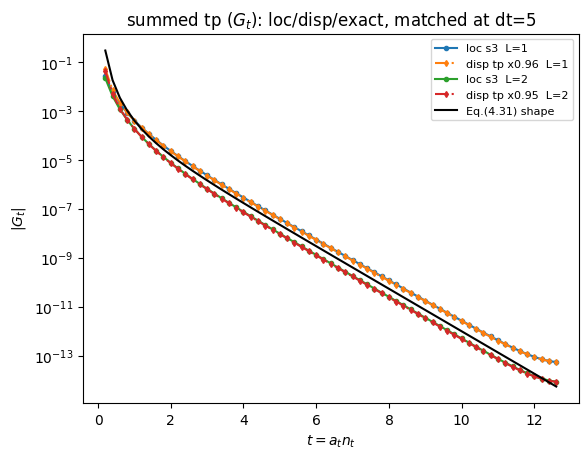

In [10]:
# tp (G_t, Eq.4.31): summed loc s3 vs disp tp vs exact tp, L=1,2.  Each matched to loc at dt=ref; |.| log.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
for L in [1, 2]:
    gl = loc_Gt(L)
    plt.plot(t, -gl[dt], 'o-', ms=3, label='loc s3  L=%d' % L)
    try:
        gd = disp_Gt(L); cd = gl[ref]/gd[ref]
        plt.plot(t, -cd*gd[dt], 'd-.', ms=3, label='disp tp x%.2f  L=%d' % (cd, L))
    except (OSError, KeyError):
        print('disp tp L=%d missing' % L)
    try:
        ge = ex_Gt(L); ce = gl[ref]/ge[ref]
        plt.plot(t, -ce*ge[dt], 's--', ms=3, label='exact tp x%.2f  L=%d' % (ce, L))
    except (OSError, KeyError):
        print('exact tp L=%d missing' % L)
A = loc_Gt(1)[ref] / cft_shape(t[ref-1])
plt.plot(t, -A*cft_shape(t), 'k-', label='Eq.(4.31) shape')
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|G_t|$')
plt.title('summed tp ($G_t$): loc/disp/exact, matched at dt=%d' % ref); plt.legend(fontsize=8)
plt.savefig('comp_trio_sum_tp.pdf', bbox_inches='tight')

exact sp L=1 missing
exact sp L=2 missing


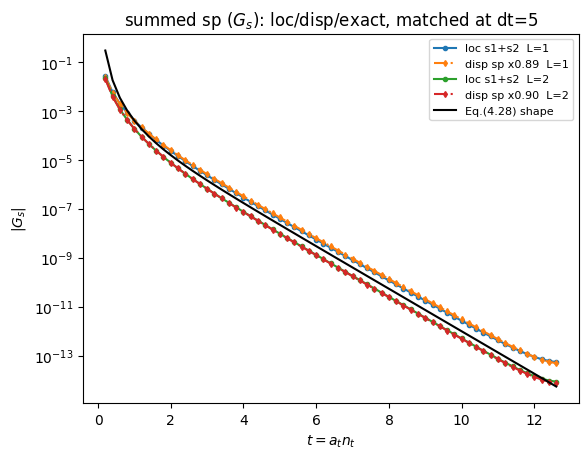

In [11]:
# sp (G_s, Eq.4.28): summed loc s1+s2 vs disp sp vs exact sp, L=1,2.  Each matched to loc at dt=ref; log.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
for L in [1, 2]:
    gl = loc_Gs(L)
    plt.plot(t, gl[dt], 'o-', ms=3, label='loc s1+s2  L=%d' % L)
    try:
        gd = disp_Gs(L); cd = gl[ref]/gd[ref]
        plt.plot(t, cd*gd[dt], 'd-.', ms=3, label='disp sp x%.2f  L=%d' % (cd, L))
    except (OSError, KeyError):
        print('disp sp L=%d missing' % L)
    try:
        ge = ex_Gs(L); ce = gl[ref]/ge[ref]
        plt.plot(t, ce*ge[dt], 's--', ms=3, label='exact sp x%.2f  L=%d' % (ce, L))
    except (OSError, KeyError):
        print('exact sp L=%d missing' % L)
A = loc_Gs(1)[ref] / cft_shape(t[ref-1])
plt.plot(t, A*cft_shape(t), 'k-', label='Eq.(4.28) shape')
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|G_s|$')
plt.title('summed sp ($G_s$): loc/disp/exact, matched at dt=%d' % ref); plt.legend(fontsize=8)
plt.savefig('comp_trio_sum_sp.pdf', bbox_inches='tight')

In [12]:
# SIGN + magnitude table at dt=5 (summed, normalized; area + 1/4pi).  tp<0, sp>0 expected.
print('%-6s %-13s %-13s %-13s | %-15s %-13s %-13s' % (
    'L','loc_Gt(s3)','disp_tp','exact_tp','loc_Gs(s1+s2)','disp_sp','exact_sp'))
for L in [1, 2]:
    def g(f):
        try: return '% .3e' % f(L)[5]
        except (OSError, KeyError): return '   --      '
    print('L=%-4d %-13s %-13s %-13s | %-15s %-13s %-13s' % (
        L, g(loc_Gt), g(disp_Gt), g(ex_Gt), g(loc_Gs), g(disp_Gs), g(ex_Gs)))
print('\n(All three are the area-weighted Eq.(4.29) sums of normalized currents.  tp<0, sp>0; the')
print(' magnitudes share the continuum C_J up to each operator s lattice Z + (exact) GW dressing.)')

L      loc_Gt(s3)    disp_tp       exact_tp      | loc_Gs(s1+s2)   disp_sp       exact_sp     
L=1    -4.130e-04    -4.301e-04       --         |  4.130e-04       4.624e-04       --        
L=2    -1.896e-04    -1.992e-04       --         |  1.896e-04       2.118e-04       --        

(All three are the area-weighted Eq.(4.29) sums of normalized currents.  tp<0, sp>0; the
 magnitudes share the continuum C_J up to each operator s lattice Z + (exact) GW dressing.)


L      loc Gs/Gt        disp Gs/Gt       exact Gs/Gt     
L=1    -1.0000          -1.0750             --           
L=2    -1.0000          -1.0635             --           

(All three -> -1.  loc divides by D-1 (sums s1+s2); disp/exact are single-direction link currents,
 no division.  Code unchanged; the D-1 handling is analysis-side only.)


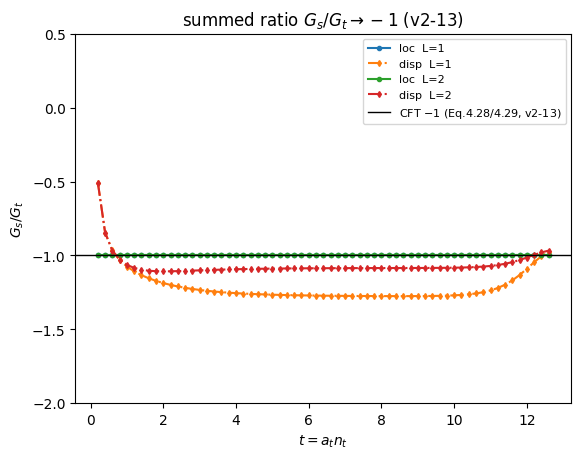

In [13]:
# RATIO G_s/G_t -> -1 (qed3int_v2-13, Eq.4.28/4.29).  Per-direction: loc G_s = (s1+s2)/(D-1) (loc sums
# the D-1 Pauli channels; its raw s1+s2/s3 = -2), disp/exact G_s = sp (link currents already per-direction,
# raw -1).  G_t = temporal (one direction).  All -> -1, opposite sp/tp sign.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
print('%-6s %-16s %-16s %-16s' % ('L','loc Gs/Gt','disp Gs/Gt','exact Gs/Gt'))
for L in [1, 2]:
    sl = sd = se = '   --   '
    try:
        rl = loc_Gs(L) / loc_Gt(L)
        plt.plot(t, rl[dt], 'o-', ms=3, label='loc  L=%d' % L)
        sl = '% .4f' % rl[ref]
    except (OSError, KeyError):
        pass
    try:
        rd = disp_Gs(L) / disp_Gt(L)
        plt.plot(t, rd[dt], 'd-.', ms=3, label='disp  L=%d' % L)
        sd = '% .4f' % rd[ref]
    except (OSError, KeyError):
        pass
    try:
        re = ex_Gs(L) / ex_Gt(L)
        plt.plot(t, re[dt], '^:', ms=3, label='exact  L=%d' % L)
        se = '% .4f' % re[ref]
    except (OSError, KeyError):
        pass
    print('L=%-4d %-16s %-16s %-16s' % (L, sl, sd, se))
plt.axhline(-1.0, color='k', ls='-', lw=1, label=r'CFT $-1$ (Eq.4.28/4.29, v2-13)')
plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$G_s/G_t$')
plt.ylim(-2.0, 0.5)
plt.title(r'summed ratio $G_s/G_t \to -1$ (v2-13)'); plt.legend(fontsize=8)
plt.savefig('comp_trio_sum_ratio.pdf', bbox_inches='tight')
print('\n(All three -> -1.  loc divides by D-1 (sums s1+s2); disp/exact are single-direction link currents,')
print(' no division.  Code unchanged; the D-1 handling is analysis-side only.)')

## Ylm tower — Eq.(4.36) (qed3int_v2-13)

$Y_{\ell m}$-projected **temporal** current (descendants of $G^t$):
$$
g_\ell(t)=\frac{1}{2\ell+1}\sum_m \mathrm{tr}[\Sigma_{\ell m}(t_0)\,P\,\Sigma_{\ell m}(t)\,P],
\qquad \Sigma_{\ell m}=\sum_n A_n Y_{\ell m}(\hat n)\,J^t_{\rm norm}(n),\ A_n=\texttt{dual\_areas}.
$$
- **loc** (`corr_deter_local`, key `ylm/l{0,1,2}`): $J^t_{\rm norm}=\sigma_3$ on-site. (already produced)
- **disp** (`corr_deter_disp`): $J^t_{\rm norm}=W^t_d=C^t/\kappa_t$ (temporal link). (rerun `tmp_summed_fast` to produce)
- **exact** (`corr_deter_exactsum`): $J^t_{\rm norm}=K^t/\kappa_t$ (overlap conserved). (rerun `--sum` with the ylm-augmented binary)

CFT tower (Eq.4.36): $g_1\to -\tfrac13 C_j e^{-2t}$, $g_2\to -\tfrac45 C_j e^{-3t}$, $g_0\to 0$ (charge conservation;
on the icosahedron $\ell=0$ leaks only at $\ell=6$).  Convention-free checks: decay rates $(2,3)$;
ratio $g_2 e^{3t}/g_1 e^{2t}\to \tfrac{4/5}{1/3}=\tfrac{12}{5}=2.4$; $g_0/g_1\to0$.

In [14]:
# Ylm loaders (Eq.4.36): g_l from h0/t0_0/ylm/l{0,1,2}/Vpp.  No 1/(D-1) here (this is the temporal tower).
def loc_gl(L, l):  return load_Vpp('corr_deter_local_%sL%d'%(tag,L),   'ylm/l%d'%l).real
def disp_gl(L, l): return load_Vpp('corr_deter_disp_%sL%d'%(tag,L),    'ylm/l%d'%l).real
def ex_gl(L, l):   return load_Vpp('corr_deter_exactsum_%sL%d'%(tag,L),'ylm/l%d'%l).real
YOPS = [('loc', loc_gl, 'o-'), ('disp', disp_gl, 'd-.'), ('exact', ex_gl, 's--')]

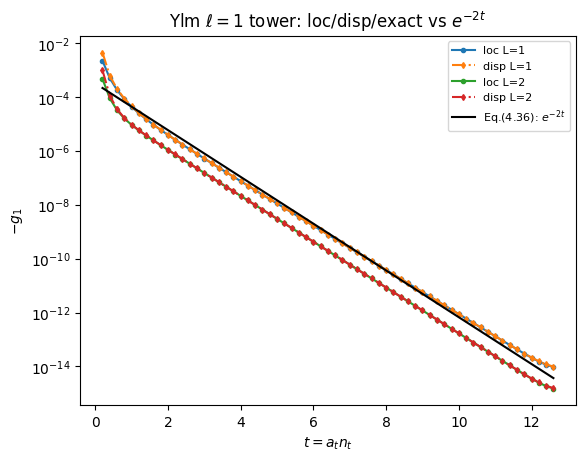

In [15]:
# ell=1 tower: -g_1 (loc/disp/exact) vs e^{-2t}, L=1,2.  |.| log; reference anchored to loc L=1.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
for L in [1, 2]:
    for name, f, mk in YOPS:
        try:
            g = f(L, 1)
            plt.plot(t, -g[dt], mk, ms=3, label='%s L=%d' % (name, L))
        except (OSError, KeyError):
            pass
try:
    g = loc_gl(1, 1); A = -g[ref] / np.exp(-2.0*t[ref-1])
    plt.plot(t, A*np.exp(-2.0*t), 'k-', label=r'Eq.(4.36): $e^{-2t}$')
except (OSError, KeyError):
    pass
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$-g_1$')
plt.title(r'Ylm $\ell=1$ tower: loc/disp/exact vs $e^{-2t}$'); plt.legend(fontsize=8)
plt.savefig('comp_trio_ylm_l1.pdf', bbox_inches='tight')

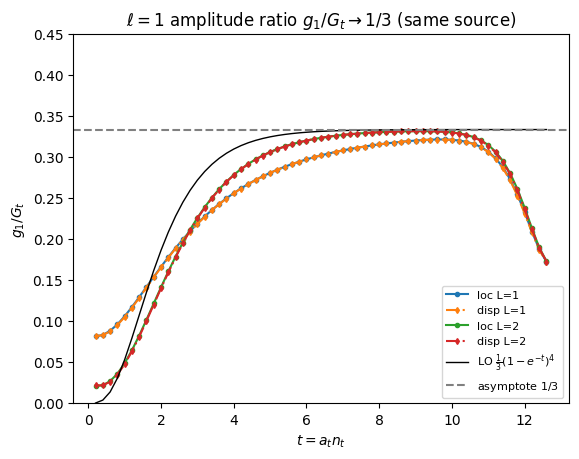

In [16]:
# ell=1 AMPLITUDE ratio g_1 / G_t (SAME source type), loc/disp/exact, L=1,2.
# CFT: g_1 -> -1/3 C_j e^{-2t} (Eq.4.36) and G_t -> -C_j e^{-2t}(1-e^{-t})^{-4} (Eq.4.31), so C_j cancels:
#   g_1/G_t -> 1/3 at large t; to leading order g_1/G_t = (1/3)(1-e^{-t})^4 (the small-t block bend).
# G_t = loc s3 / disp tp / exact tp (the temporal correlator, NOT the /(D-1) spatial).
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
GT = {'loc': loc_Gt, 'disp': disp_Gt, 'exact': ex_Gt}
plt.figure()
for L in [1, 2]:
    for name, f, mk in YOPS:
        try:
            g1 = f(L, 1); gt = GT[name](L)
            plt.plot(t, g1[dt]/gt[dt], mk, ms=3, label='%s L=%d' % (name, L))
        except (OSError, KeyError):
            pass
plt.plot(t, (1.0/3.0)*(1.0-np.exp(-t))**4, 'k-', lw=1, label=r'LO $\frac{1}{3}(1-e^{-t})^4$')
plt.axhline(1.0/3.0, color='gray', ls='dashed', label=r'asymptote $1/3$')
plt.ylim(0, 0.45); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$g_1 / G_t$')
plt.title(r'$\ell=1$ amplitude ratio $g_1/G_t\to 1/3$ (same source)'); plt.legend(fontsize=8)
plt.savefig('comp_trio_ylm_g1_over_Gt.pdf', bbox_inches='tight')

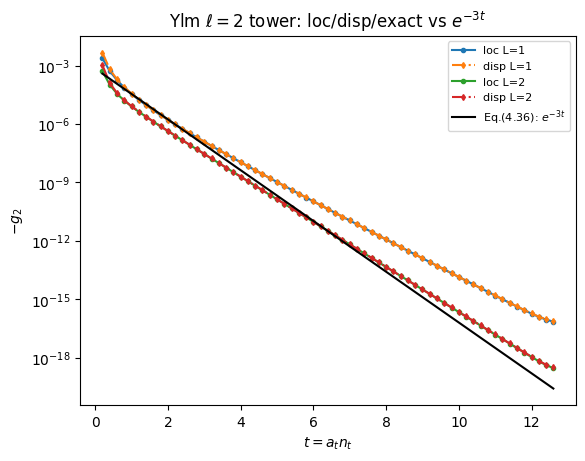

In [17]:
# ell=2 tower: -g_2 (loc/disp/exact) vs e^{-3t}, L=1,2.  |.| log; reference anchored to loc L=1.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
for L in [1, 2]:
    for name, f, mk in YOPS:
        try:
            g = f(L, 2)
            plt.plot(t, -g[dt], mk, ms=3, label='%s L=%d' % (name, L))
        except (OSError, KeyError):
            pass
try:
    g = loc_gl(1, 2); A = -g[ref] / np.exp(-3.0*t[ref-1])
    plt.plot(t, A*np.exp(-3.0*t), 'k-', label=r'Eq.(4.36): $e^{-3t}$')
except (OSError, KeyError):
    pass
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$-g_2$')
plt.title(r'Ylm $\ell=2$ tower: loc/disp/exact vs $e^{-3t}$'); plt.legend(fontsize=8)
plt.savefig('comp_trio_ylm_l2.pdf', bbox_inches='tight')

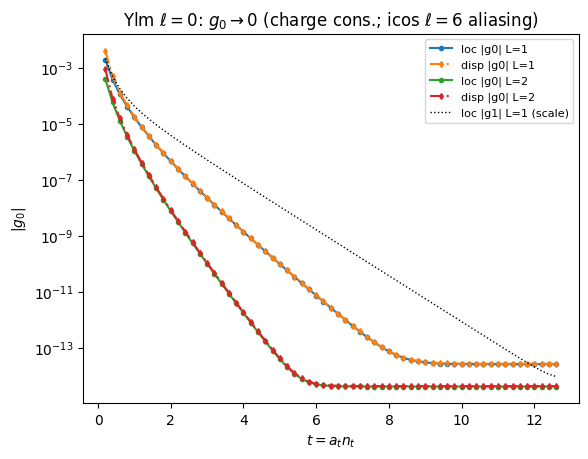

In [18]:
# ell=0 mode: |g_0| (loc/disp/exact, L=1,2).  CFT: g0 -> 0 (charge conservation, Q|0>=0).  On the
# icosahedron (spherical 5-design) it leaks only at l=6, so |g0| ~ E_6^2 (shrinks ~1/L^4 with L, fixed
# rate e^{-7t}) -- a tiny vanishing mode, far below g1.  |.| used since this null mode has no physical sign.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
for L in [1, 2]:
    for name, f, mk in YOPS:
        try:
            g0 = f(L, 0)
            plt.plot(t, np.abs(g0[dt]), mk, ms=3, label='%s |g0| L=%d' % (name, L))
        except (OSError, KeyError):
            pass
try:  # loc |g1| L=1 as a scale reference: g0 should sit well below the l=1 tower
    g1 = loc_gl(1, 1); plt.plot(t, np.abs(g1[dt]), 'k:', lw=1, label='loc |g1| L=1 (scale)')
except (OSError, KeyError):
    pass
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|g_0|$')
plt.title(r'Ylm $\ell=0$: $g_0\to 0$ (charge cons.; icos $\ell=6$ aliasing)'); plt.legend(fontsize=8)
plt.savefig('comp_trio_ylm_l0.pdf', bbox_inches='tight')

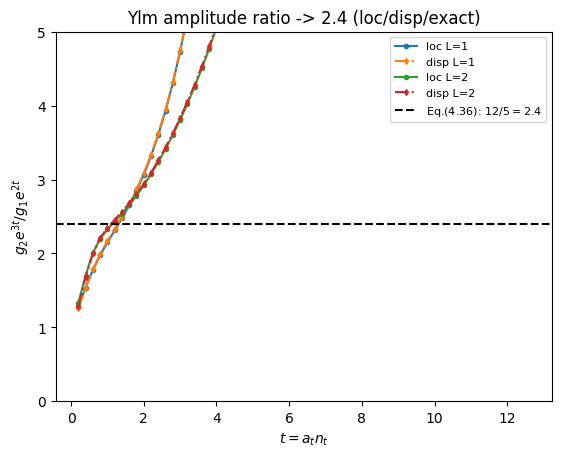

In [19]:
# Ylm amplitude ratio g_2 e^{3t} / g_1 e^{2t} -> 12/5 = 2.4 (Eq.4.36), loc/disp/exact, L=1,2.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
plt.figure()
for L in [1, 2]:
    for name, f, mk in YOPS:
        try:
            g1 = f(L, 1); g2 = f(L, 2)
            plt.plot(t, (g2[dt]*np.exp(3.0*t))/(g1[dt]*np.exp(2.0*t)), mk, ms=3, label='%s L=%d' % (name, L))
        except (OSError, KeyError):
            pass
plt.axhline(12.0/5.0, color='k', ls='dashed', label=r'Eq.(4.36): $12/5=2.4$')
plt.ylim(0, 5); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$g_2 e^{3t}/g_1 e^{2t}$')
plt.title('Ylm amplitude ratio -> 2.4 (loc/disp/exact)'); plt.legend(fontsize=8)
plt.savefig('comp_trio_ylm_ratio.pdf', bbox_inches='tight')

In [20]:
# Ylm convention-free checks (print): effective decay rates -> (2,3); g_2 e^{3t}/g_1 e^{2t} -> 2.4; g0/g1 -> 0.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
def eff_rate(g):  # m_eff(t) = -(1/at) log( g[n+1]/g[n] ), mid-t window
    gg = g[dt]; return -np.log(gg[1:]/gg[:-1]) / at_cft
print('predicted: l=1 rate 2.0, l=2 rate 3.0, ratio 2.4, g0/g1 -> 0')
for L in [1, 2]:
    for name, f, _ in YOPS:
        try:
            g0 = f(L,0); g1 = f(L,1); g2 = f(L,2)
            r1 = np.round(np.mean(eff_rate(g1)[14:20]), 3)
            r2 = np.round(np.mean(eff_rate(g2)[14:20]), 3)
            rat = np.round(np.mean(((g2[dt]*np.exp(3*t))/(g1[dt]*np.exp(2*t)))[12:20]), 3)
            g0g1 = np.round((g0[dt]/g1[dt])[5], 5)
            print('%-6s L=%d: rate(l1)=%s rate(l2)=%s  ratio=%s  g0/g1[5]=%s' % (name, L, r1, r2, rat, g0g1))
        except (OSError, KeyError):
            print('%-6s L=%d: missing' % (name, L))

predicted: l=1 rate 2.0, l=2 rate 3.0, ratio 2.4, g0/g1 -> 0
loc    L=1: rate(l1)=1.932 rate(l2)=2.41  ratio=5.672  g0/g1[5]=0.30695
disp   L=1: rate(l1)=1.933 rate(l2)=2.412  ratio=5.696  g0/g1[5]=0.31897
exact  L=1: missing
loc    L=2: rate(l1)=1.961 rate(l2)=2.677  ratio=4.18  g0/g1[5]=0.06479
disp   L=2: rate(l1)=1.962 rate(l2)=2.679  ratio=4.207  g0/g1[5]=0.07116
exact  L=2: missing
